In [3]:
# Import python libraries
import osmnx as osm
import geopandas as gpd
import matplotlib.pyplot as plt
import hvplot.pandas
import geoviews
import holoviews as hv

/opt/conda/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


In [4]:
# Look for everything labeled 'University' within 1000m of an address
ASC = osm.features_from_address(
    'Decatur, Dekalb County, Georgia',
    {'amenity': ['college']}) # adjust dist= to find more buildings
ASC

,,amenity,ele,gnis:feature_id,name,website,wikidata,wikipedia,geometry,nodes
element_type,osmid,,,,,,,,,
node,358710274,college,317,325858,Agnes Scott College,https://agnesscott.edu/,Q2826926,en:Agnes Scott College,POINT (-84.29445 33.76889),NaN
way,28523209,college,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((-84.29809 33.76906, -84.28962 33.771...","[313309979, 313309980, 405869971, 313309981, 3..."


In [5]:

ASC = osm.geocode_to_gdf("W28523209", by_osmid=True)

<Axes: >

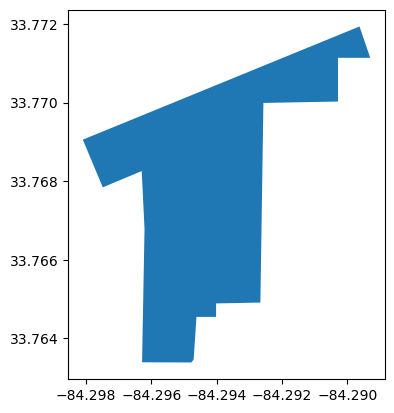

In [6]:
ASC.plot()

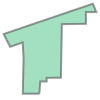

In [7]:
# Extract ploygon from geometry
polygon = ASC.geometry.iloc[0]
polygon

In [12]:
# Get buildings with the polygon using features_from_polygon()
building = osm.features_from_polygon(polygon, tags={"building": True})
building

nodes  \
element_type osmid                                                          
way          40803848   [496120097, 1018406280, 1018406312, 1018406359...   
             40897634   [497811879, 497811882, 497811868, 660541772, 4...   
             51277860   [654219349, 654219350, 654219351, 654219352, 6...   
             51277869   [654219467, 654219468, 654219470, 654219471, 6...   
             51278158   [654222327, 654222329, 654222331, 654222333, 6...   
...                                                                   ...   
             87539104   [1018406252, 1021511381, 654418843, 654418844,...   
             87539110   [654418839, 1018406255, 654418906, 654418907, ...   
             87893395   [654418904, 654418906, 1021511362, 1018406255,...   
             429350916  [4284744105, 4284744106, 4284744107, 428474410...   
             429351041  [4284746828, 4284746829, 4284746830, 428474683...   

                       building  \
element_type osmid                
way          40803848       yes   
             40897634       yes   
             51277860       yes   
             51277869       yes   
             51278158       yes   
...                         ...   
             87539104       yes   
             87539110    school   
             87893395      roof   
             429350916      yes   
             429351041      yes   

                                                                 geometry  \
element_type osmid                                                          
way          40803848   POLYGON ((-84.29410 33.76524, -84.29410 33.765...   
             40897634   POLYGON ((-84.29654 33.76822, -84.29664 33.768...   
             51277860   POLYGON ((-84.29299 33.76667, -84.29299 33.766...   
             51277869   POLYGON ((-84.29522 33.76654, -84.29546 33.766...   
             51278158   POLYGON ((-84.29315 33.76492, -84.29323 33.764...   
...                                                                   ...   
             87539104   POLYGON ((-84.29508 33.76925, -84.29508 33.769...   
             87539110   POLYGON ((-84.29481 33.76921, -84.29483 33.769...   
             87893395   POLYGON ((-84.29490 33.76925, -84.29483 33.769...   
             429350916  POLYGON ((-84.29741 33.76791, -84.29733 33.767...   
             429351041  POLYGON ((-84.29398 33.76773, -84.29398 33.767...   

                       amenity                         name DeKalb:id  \
element_type osmid                                                      
way          40803848      NaN                          NaN       NaN   
             40897634   police    Agnes Scott Public Safety       NaN   
             51277860      NaN                          NaN    111576   
             51277869      NaN                 Dance Center    111672   
             51278158      NaN                          NaN    108796   
...                        ...                          ...       ...   
             87539104      NaN           Rebekah Scott Hall    115384   
             87539110      NaN             Agnes Scott Hall    115384   
             87893395      NaN                          NaN    115384   
             429350916     NaN                          NaN       NaN   
             429351041     NaN  Julia Thompson Smith Chapel       NaN   

                       operator:type website parking  
element_type osmid                                    
way          40803848            NaN     NaN     NaN  
             40897634            NaN     NaN     NaN  
             51277860            NaN     NaN     NaN  
             51277869            NaN     NaN     NaN  
             51278158            NaN     NaN     NaN  
...                              ...     ...     ...  
             87539104            NaN     NaN     NaN  
             87539110            NaN     NaN     NaN  
             87893395            NaN     NaN     NaN  
             429350916           NaN     NaN     NaN 

<Axes: >

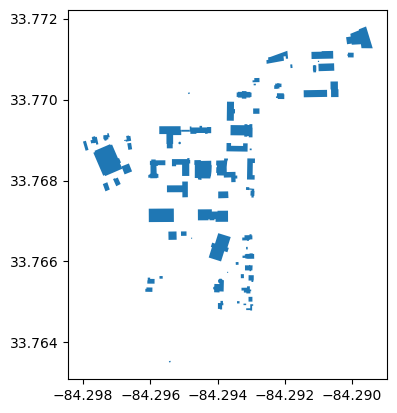

In [11]:
# Plot the buildings
building.plot()

In [14]:
# Get roads
roads = osm.features_from_polygon(polygon,
                                      tags={"highway": True})
roads

highway  \
element_type osmid                  
node         567034080   crossing   
             567034130   crossing   
             937205769   crossing   
             937205772   crossing   
             1018406241  crossing   
...                           ...   
way          1388184690   footway   
             1388186613   footway   
             1388186614   footway   
             1388186615   footway   
             1484925143   service   

                                                                  geometry  \
element_type osmid                                                           
node         567034080                          POINT (-84.29641 33.76862)   
             567034130                          POINT (-84.29470 33.76682)   
             937205769                          POINT (-84.29261 33.76804)   
             937205772                          POINT (-84.29264 33.76680)   
             1018406241                         POINT (-84.29416 33.76683)   
...                                                                    ...   
way          1388184690  LINESTRING (-84.29388 33.77057, -84.29388 33.7...   
             1388186613  LINESTRING (-84.29641 33.76799, -84.29647 33.7...   
             1388186614  LINESTRING (-84.29647 33.76855, -84.29648 33.7...   
             1388186615  LINESTRING (-84.29649 33.76869, -84.29642 33.7...   
             1484925143  LINESTRING (-84.29033 33.77159, -84.29028 33.7...   

                             crossing crossing:markings tactile_paving  \
element_type osmid                                                       
node         567034080            NaN               NaN            NaN   
             567034130            NaN               NaN            NaN   
             937205769            NaN               NaN            NaN   
             937205772   uncontrolled               yes            NaN   
             1018406241           NaN               NaN            NaN   
...                               ...               ...            ...   
way          1388184690           NaN               NaN            NaN   
             1388186613           NaN               NaN            NaN   
             1388186614  uncontrolled                no            NaN   
             1388186615      unmarked                no            NaN   
             1484925143           NaN               NaN            NaN   

                                                                     nodes  \
element_type osmid                                                           
node         567034080                                                 NaN   
             567034130                                                 NaN   
             937205769                                                 NaN   
             937205772                                                 NaN   
             1018406241                                                NaN   
...                                                                    ...   
way          1388184690  [12840388577, 12850497135, 12850497136, 128504...   
             1388186613                         [12849481362, 11305122460]   
             1388186614             [11305122460, 1376100596, 12850493000]   
             1388186615            [12850493000, 12850525201, 12848929922]   
             1484925143  [13614350349, 13614350352, 13614350350, 136143...   

                        access name tiger:cfcc tiger:county  ... lanes  ref  \
element_type osmid                                           ...              
node         567034080     NaN  NaN        NaN          NaN  ...   NaN  NaN   
             567034130     NaN  NaN        NaN          NaN  ...   NaN  NaN   
             937205769     NaN  NaN        NaN          NaN  ...   NaN  NaN   
             937205772     NaN  NaN        NaN          NaN  ...   NaN  NaN   
             1018406241    NaN  NaN        NaN          NaN  ...   NaN  NaN  

<Axes: >

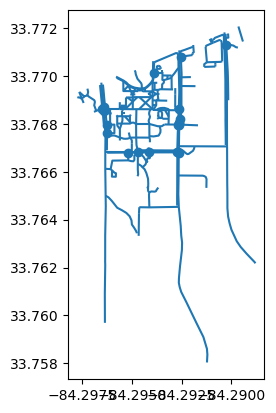

In [15]:
roads.plot()

<Axes: >

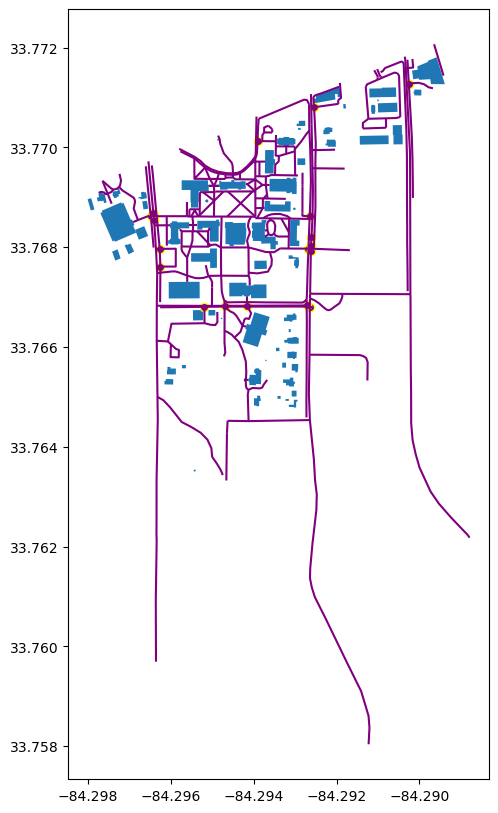

In [16]:
# Plot roads and boundary together 
fig, ax = plt.subplots(figsize=(10,10))
building.plot(ax=ax)
roads.plot(ax=ax, color='purple', edgecolor='yellow')

In [17]:
# Clip roads to campus boundary
roads_clipped = gpd.clip(
    roads,
    polygon
)

roads_clipped

highway  \
element_type osmid                    
way          82905182     secondary   
             9189174    residential   
             733504198      service   
             9186045    residential   
             9188430    residential   
...                             ...   
             72147241       footway   
             72147242       footway   
             72147245       footway   
             43300165       footway   
             9185682    residential   

                                                                 geometry  \
element_type osmid                                                          
way          82905182   LINESTRING (-84.29264 33.76683, -84.29264 33.7...   
             9189174    LINESTRING (-84.29265 33.76584, -84.29264 33.7...   
             733504198  LINESTRING (-84.29264 33.76698, -84.29262 33.7...   
             9186045    LINESTRING (-84.29034 33.77170, -84.29033 33.7...   
             9188430    LINESTRING (-84.29264 33.76707, -84.29262 33.7...   
...                                                                   ...   
             72147241   LINESTRING (-84.29497 33.76925, -84.29505 33.7...   
             72147242   LINESTRING (-84.29543 33.76978, -84.29543 33.7...   
             72147245   LINESTRING (-84.29567 33.76988, -84.29543 33.7...   
             43300165   LINESTRING (-84.29482 33.77017, -84.29482 33.7...   
             9185682    LINESTRING (-84.29562 33.76990, -84.29542 33.7...   

                       crossing crossing:markings tactile_paving  \
element_type osmid                                                 
way          82905182       NaN               NaN            NaN   
             9189174        NaN               NaN            NaN   
             733504198      NaN               NaN            NaN   
             9186045        NaN               NaN            NaN   
             9188430        NaN               NaN            NaN   
...                         ...               ...            ...   
             72147241       NaN               NaN            NaN   
             72147242       NaN               NaN            NaN   
             72147245       NaN               NaN            NaN   
             43300165       NaN               NaN            NaN   
             9185682        NaN               NaN            NaN   

                                                                    nodes  \
element_type osmid                                                          
way          82905182   [68331408, 937205772, 68331409, 68331411, 6828...   
             9189174    [68331409, 12849414796, 68421998, 68422000, 68...   
             733504198  [6869287623, 12849414793, 6869287624, 68692876...   
             9186045    [68331821, 6568153403, 6568153417, 13614350349...   
             9188430    [68331405, 6568153382, 6568153647, 6869287634,...   
...                                                                   ...   
             72147241                   [654418894, 857626140, 857626146]   
             72147242                   [857626152, 857626155, 857626146]   
             72147245   [5091989750, 857626152, 857626146, 857626168, ...   
             43300165   [5674630527, 544047956, 544047960, 544047968, ...   
             9185682    [249489228, 5674630526, 249489237, 249489236, ...   

                         access                  name tiger:cfcc tiger:county  \
element_type osmid                                                              
way          82905182       NaN  South Candler Street        A31   DeKalb, GA   
             9189174        NaN         Bruton Street        A41   DeKalb, GA   
             733504198  private                   NaN        NaN          NaN   
             9186045        NaN          Avery Street        A41   DeKalb, GA   
             9188430        NaN         Winnona Drive        A41   DeKalb, GA   
...                         ...                   ...        ...

<Axes: >

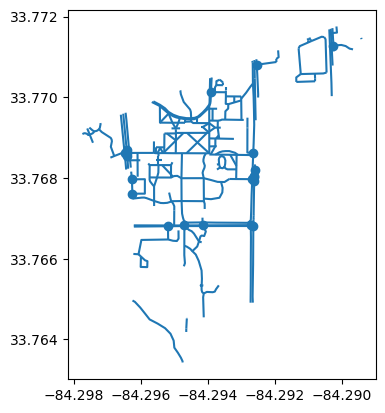

In [18]:
roads_clipped.plot()